# Nghiên Cứu Ablation Study: So Sánh Trực Tiếp Các Biến Thể Mamba-Hybrid

Notebook này thực hiện so sánh trực tiếp hiệu năng của 6 biến thể trong nghiên cứu **Ablation Study** của mô hình `Mamba-Hybrid` nhằm đánh giá vai trò của từng thành phần cốt lõi:
1. **RevIN** (Reversible Instance Normalization): Chuẩn hóa ngược dòng để chống trượt phân phối dữ liệu.
2. **Decomposition** (Series Decomposition): Tách chuỗi thời gian thành xu hướng (Trend) và chu kỳ (Seasonal).
3. **Multiscale Patching**: Trích xuất đặc trưng đa quy mô thời gian (Short-term & Long-term).
4. **Physical Statistics**: Bổ sung các đặc trưng thống kê vật lý rung động (Mean, Std, RMS, Kurtosis, Crest Factor, Shape Factor, ...).

### Các cấu hình được so sánh:
* **Full**: Kích hoạt toàn bộ 4 thành phần (`use_revin: true`, `use_decomposition: true`, `use_multiscale: true`, `use_stats: true`)
* **WO_RevIN**: Loại bỏ RevIN
* **WO_Decomposition**: Loại bỏ Series Decomposition
* **WO_Multiscale**: Loại bỏ Multiscale Patching (chỉ dùng single-scale)
* **WO_PhysicalStats**: Loại bỏ các đặc trưng thống kê vật lý
* **Vanilla**: Loại bỏ toàn bộ 4 thành phần (chỉ dự báo thuần túy từ tín hiệu thô)

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 49.1 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [2]:
import os
import sys
import time
import gc
import yaml
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_curve, auc as auc_score_func

# 1. Phát hiện môi trường Kaggle và cấu hình đường dẫn dữ liệu
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

if is_kaggle:
    kaggle_source_root = '/kaggle/input/datasets/sunbv21/mamba-sft-source'
    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root
    
    train_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B02", 
                  "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    test_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B01",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B03",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B04",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    models_dir = "/kaggle/working/results/models"
    print(f'-> [Kaggle] project_root: {project_root}')
    print(f'-> [Kaggle] models_dir: {models_dir}')
else:
    project_root = os.path.abspath("../")
    if project_root not in sys.path:
        sys.path.append(project_root)
        
    train_dirs = ["data/processed/B02", "data/processed/B05"]
    test_dirs = ["data/processed/B01", "data/processed/B03", "data/processed/B04", "data/processed/B05"]
    # Đảm bảo đường dẫn tuyệt đối cho local
    train_dirs = [os.path.join(project_root, d) for d in train_dirs]
    test_dirs = [os.path.join(project_root, d) for d in test_dirs]
    models_dir = os.path.join(project_root, "results/models")
    print(f'-> [Local] project_root: {project_root}')
    print(f'-> [Local] models_dir: {models_dir}')

from src.data import MultiBearingDataset
from src.models.mamba import HybridMambaCNN
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma, calculate_threshold_robust, 
    calculate_threshold_percentile, calculate_threshold_pot,
    calculate_threshold_gmm, find_best_threshold, calculate_metrics
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Is running on Kaggle: True
-> [Kaggle] project_root: /kaggle/input/datasets/sunbv21/mamba-sft-source
-> [Kaggle] models_dir: /kaggle/working/results/models
Using device: cuda


In [3]:
# 2. Đường dẫn cấu hình và nạp dữ liệu
configs_dir = os.path.join(project_root, "configs")

# Ánh xạ tên biến thể ablation sang file YAML cấu hình tương ứng
ablation_configs = {
    "Full": "snano_full.yaml",
    "WO_RevIN": "snano_wo_revin.yaml",
    "WO_Decomposition": "snano_wo_decomp.yaml",
    "WO_Multiscale": "snano_wo_multiscale.yaml",
    "WO_PhysicalStats": "snano_wo_stats.yaml",
    "Vanilla": "snano_vanilla.yaml"
}

# Tải cấu hình nền (Full) để thiết lập dataset
base_config_path = os.path.join(configs_dir, ablation_configs["Full"])
with open(base_config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

window_stride = config['data'].get('window_stride', 1024)
lookback = config['data'].get('lookback', 4096)
horizon = config['data'].get('horizon', 1024)
sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = config['data'].get('highpass_freq', 1000)
train_ratio = config['data'].get('train_ratio', 0.5)
skip_ratio = config['data'].get('skip_ratio', 0.1)
label_strategy = config['data'].get('label_strategy', 'rms')
batch_size = 128

print("Đang tải dữ liệu huấn luyện để trích xuất thống kê điều kiện vận hành (Operating Conditions)...")
train_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='train',
    file_sample_ratio=1, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)
oc_stats = train_dataset.oc_stats

print("Đang tải dữ liệu validation...")
val_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)

print("Đang tải tập dữ liệu kiểm thử (4 Vòng Bi)...")
test_dataset = MultiBearingDataset(
    test_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='test',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n--- Tải dữ liệu thành công ---")
print(f"Số lượng mẫu test: {len(test_dataset):,}")

Đang tải dữ liệu huấn luyện để trích xuất thống kê điều kiện vận hành (Operating Conditions)...
Đang tải dữ liệu validation...
Đang tải tập dữ liệu kiểm thử (4 Vòng Bi)...

--- Tải dữ liệu thành công ---
Số lượng mẫu test: 535,400


In [4]:
def load_ablation_model(variant_name, yaml_filename, device):
    yaml_path = os.path.join(configs_dir, yaml_filename)
    with open(yaml_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
        
    # Khởi tạo mô hình HybridMambaCNN đúng với các cờ ablation
    model = HybridMambaCNN({
        'model': {
            'mamba_version': 1,
            'mamba_d_model': cfg['model'].get('mamba_d_model', 64),
            'mamba_n_layer': cfg['model'].get('mamba_n_layer', 4),
            'mamba_d_state': cfg['model'].get('mamba_d_state', 16),
            'mamba_d_conv': cfg['model'].get('mamba_d_conv', 4),
            'mamba_expand': cfg['model'].get('mamba_expand', 2),
            'forecast_len': horizon,
            'patch_size': cfg['model'].get('patch_size', 64),
            'stride': cfg['model'].get('patch_stride', 32),
            'trend_downsample': cfg['model'].get('trend_downsample', 1),
            'in_channels': 2, 'lookback': lookback,
            'decomp_kernel': cfg['model'].get('decomp_kernel', 25),
            'use_multiscale': cfg['model'].get('use_multiscale', True),
            'use_revin': cfg['model'].get('use_revin', True),
            'use_decomposition': cfg['model'].get('use_decomposition', True),
            'use_stats': cfg['model'].get('use_stats', True),
        },
        'data': {
            'patch_size': cfg['model'].get('patch_size', 64),
            'stride': cfg['model'].get('patch_stride', 32),
            'lookback': lookback
        }
    })
    
    # Bản đồ tên checkpoint
    checkpoint_name = f"mamba1_hybrid_snano_{variant_name.lower()}_best.pth"
    checkpoint_path = os.path.join(models_dir, checkpoint_name)
    
    if os.path.exists(checkpoint_path):
        print(f"Đang tải checkpoint: {checkpoint_name}...")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    else:
        # Kiểm thử fallback tên slug không có số 1 nếu có
        alt_name = f"mamba_hybrid_snano_{variant_name.lower()}_best.pth"
        alt_path = os.path.join(models_dir, alt_name)
        if os.path.exists(alt_path):
            print(f"Đang tải checkpoint (fallback): {alt_name}...")
            model.load_state_dict(torch.load(alt_path, map_location=device, weights_only=True))
        else:
            print(f"⚠️ CẢNH BÁO: Không tìm thấy checkpoint cho {variant_name} tại {checkpoint_path}. Mô hình sẽ khởi chạy ngẫu nhiên!")
            
    model.to(device)
    model.eval()
    return model, cfg

In [5]:
def evaluate_variant(variant_name, model, test_loader, cfg, device):
    model.eval()
    
    macro_metrics = {
        t_name: {"F1": [], "FAR": [], "AUC": [], "AUPRC": []}
        for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]
    }
    
    macro_forecasting = {
        "MAE": [], "MSE": [], "RMSE": [], "MAPE": []
    }
    
    # Khởi tạo các danh sách đo độ trễ chi tiết
    transfer_latencies = []
    inf_latencies = []
    scoring_latencies = []
    decision_latencies = []
    total_eval_latencies = []
    
    calib_times = {
        "3-Sigma": [],
        "Robust": [],
        "Percentile": [],
        "POT": [],
        "Self-Learn": [],
        "Optimal": []
    }
    
    skip_ratio = cfg['data'].get('skip_ratio', 0.1)
    train_ratio = cfg['data'].get('train_ratio', 0.5)

    test_datasets = test_loader.dataset.datasets if hasattr(test_loader.dataset, 'datasets') else [test_loader.dataset]

    for test_idx, ds in enumerate(test_datasets):
        bearing_name = os.path.basename(ds.data_dir) if hasattr(ds, 'data_dir') else f"Bearing_{test_idx}"
        loader = DataLoader(ds, batch_size=cfg['training'].get('batch_size', 128), shuffle=False)
        
        bearing_scores = []
        bearing_labels = []
        bearing_mae_list = []
        bearing_mse_list = []
        bearing_mape_list = []
        
        with torch.no_grad():
            for batch in loader:
                # 1. Đo lường thời gian truyền dữ liệu (CPU -> GPU)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.time()
                
                x = batch[0].to(device)
                y = batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.time()
                
                # 2. Đo lường thời gian Model Inference (Forward Pass) với Autocast
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t2 = time.time()
                
                # 3. Đo lường thời gian Tính điểm bất thường (Anomaly Scoring)
                scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t3 = time.time()
                
                # 4. Đo lường thời gian Ra quyết định (Threshold Decision)
                dummy_threshold = 0.5
                is_anomaly = scores > dummy_threshold
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t4 = time.time()
                
                # Lưu trữ kết quả đo lường độ trễ trên mỗi sample (ms/sample)
                n_samples = x.size(0)
                transfer_ms = (t1 - t0) * 1000 / n_samples
                inf_ms = (t2 - t1) * 1000 / n_samples
                score_ms = (t3 - t2) * 1000 / n_samples
                decision_ms = (t4 - t3) * 1000 / n_samples
                total_ms = (t4 - t0) * 1000 / n_samples
                
                transfer_latencies.append(transfer_ms)
                inf_latencies.append(inf_ms)
                scoring_latencies.append(score_ms)
                decision_latencies.append(decision_ms)
                total_eval_latencies.append(total_ms)
                
                bearing_scores.extend(scores.tolist())

                if len(batch) > 3:
                    bearing_labels.extend(batch[3].cpu().numpy().tolist())
                else:
                    bearing_labels.extend([0] * x.size(0))

                y_cpu = y.detach().cpu().numpy()
                y_pred_cpu = y_pred.detach().cpu().numpy()
                
                batch_mae = np.mean(np.abs(y_cpu - y_pred_cpu))
                batch_mse = np.mean((y_cpu - y_pred_cpu) ** 2)
                epsilon = 1e-5
                batch_mape = np.mean(np.abs(y_cpu - y_pred_cpu) / (np.abs(y_cpu) + epsilon)) * 100
                
                bearing_mae_list.append(batch_mae)
                bearing_mse_list.append(batch_mse)
                bearing_mape_list.append(batch_mape)

        bearing_scores = np.array(bearing_scores)
        bearing_labels = np.array(bearing_labels, dtype=int)
        
        n_total = len(bearing_labels)
        
        bearing_mae = np.mean(bearing_mae_list)
        bearing_mse = np.mean(bearing_mse_list)
        bearing_rmse = np.sqrt(bearing_mse)
        bearing_mape = np.mean(bearing_mape_list)
        
        macro_forecasting["MAE"].append(bearing_mae)
        macro_forecasting["MSE"].append(bearing_mse)
        macro_forecasting["RMSE"].append(bearing_rmse)
        macro_forecasting["MAPE"].append(bearing_mape)
        
        # Thiết lập khoảng dữ liệu healthy tính ngưỡng
        skip_end = int(n_total * skip_ratio)
        train_end = int(n_total * (skip_ratio + train_ratio))
        
        normal_indices = np.where(bearing_labels == 0)[0]
        if len(normal_indices) > 0:
            train_end = min(train_end, normal_indices[-1] + 1)
            
        if train_end > skip_end:
            healthy_subset = bearing_scores[skip_end:train_end]
            healthy_labels = bearing_labels[skip_end:train_end]
            healthy_scores = healthy_subset[healthy_labels == 0]
            if len(healthy_scores) == 0:
                healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
        else:
            healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
            
        # Đo lường thời gian hiệu chuẩn từng thuật toán ngưỡng
        t_cal = time.time()
        local_th_3s  = calculate_threshold_3sigma(healthy_scores)
        calib_times["3-Sigma"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_rb  = calculate_threshold_robust(healthy_scores)
        calib_times["Robust"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pc  = calculate_threshold_percentile(healthy_scores, q=99.7)
        calib_times["Percentile"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pot = calculate_threshold_pot(healthy_scores, q=1e-3)
        calib_times["POT"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_gmm = calculate_threshold_gmm(bearing_scores)
        calib_times["Self-Learn"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_opt, _ = find_best_threshold(bearing_scores, bearing_labels)
        calib_times["Optimal"].append((time.time() - t_cal) * 1000)

        if len(np.unique(bearing_labels)) > 1:
            precision_path, recall_path, _ = precision_recall_curve(bearing_labels, bearing_scores)
            bearing_auprc = auc_score_func(recall_path, precision_path)
        else:
            bearing_auprc = 0.0

        thresholds = [
            ("3-Sigma", local_th_3s), ("Robust", local_th_rb), ("Percentile", local_th_pc),
            ("POT", local_th_pot), ("Self-Learn", local_th_gmm), ("Optimal", local_th_opt)
        ]
        
        for t_name, t_val in thresholds:
            m = calculate_metrics(bearing_scores, bearing_labels, t_val)
            macro_metrics[t_name]["F1"].append(m.get('F1', 0))
            macro_metrics[t_name]["FAR"].append(m.get('FAR', 0))
            macro_metrics[t_name]["AUC"].append(m.get('AUC', 0))
            macro_metrics[t_name]["AUPRC"].append(bearing_auprc)

    # Tính toán trung bình các chỉ số thời gian
    avg_transfer_lat = float(np.mean(transfer_latencies))
    avg_inf_lat = float(np.mean(inf_latencies))
    avg_scoring_lat = float(np.mean(scoring_latencies))
    avg_decision_lat = float(np.mean(decision_latencies))
    avg_total_eval_lat = float(np.mean(total_eval_latencies))
    avg_calib_times = {k: float(np.mean(v)) for k, v in calib_times.items()}
    
    avg_mae = float(np.mean(macro_forecasting["MAE"]))
    avg_mse = float(np.mean(macro_forecasting["MSE"]))
    avg_rmse = float(np.mean(macro_forecasting["RMSE"]))
    avg_mape = float(np.mean(macro_forecasting["MAPE"]))

    print(f"\n============================================================")
    print(f">>> MACRO-AVERAGE PERFORMANCE - VARIANT: {variant_name} ({len(test_datasets)} Bearings)")
    print(f"   [Forecasting Metrics] > MAE: {avg_mae:.6f} | MSE: {avg_mse:.6f} | RMSE: {avg_rmse:.6f} | MAPE: {avg_mape:.4f}%")
    print(f"------------------------------------------------------------")
    print(f"   [Real-time Evaluation Latency Breakdown (per sample)]:")
    print(f"     * Data Transfer (CPU->GPU): {avg_transfer_lat:.4f} ms")
    print(f"     * Model Inference (Forward): {avg_inf_lat:.4f} ms")
    print(f"     * Anomaly Scoring:           {avg_scoring_lat:.4f} ms")
    print(f"     * Decision (Threshold Cmp):  {avg_decision_lat:.4f} ms")
    print(f"     * TOTAL REAL LATENCY:        {avg_total_eval_lat:.4f} ms/sample")
    print(f"------------------------------------------------------------")
    print(f"   [Threshold Calibration Overhead (per bearing)]:")
    for k, v in avg_calib_times.items():
        print(f"     * {k:<12}: {v:.4f} ms")
    print(f"============================================================")
    
    # Tập hợp các metric Macro-Average
    res_dict = {
        "MAE": avg_mae,
        "MSE": avg_mse,
        "RMSE": avg_rmse,
        "MAPE": avg_mape,
        "Latency (ms)": avg_total_eval_lat,
        "Lat Transfer (ms)": avg_transfer_lat,
        "Lat Inference (ms)": avg_inf_lat,
        "Lat Scoring (ms)": avg_scoring_lat,
        "Lat Decision (ms)": avg_decision_lat,
    }
    
    # Thêm F1, FAR, AUC cho từng phương pháp ngưỡng
    for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]:
        res_dict[f"F1 ({t_name})"] = np.mean(macro_metrics[t_name]["F1"])
        res_dict[f"FAR ({t_name})"] = np.mean(macro_metrics[t_name]["FAR"])
        res_dict[f"AUC ({t_name})"] = np.mean(macro_metrics[t_name]["AUC"])
        res_dict[f"AUPRC ({t_name})"] = np.mean(macro_metrics[t_name]["AUPRC"])
        
    return res_dict

In [6]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


def train_ablation_variant(variant_name, model, train_loader, val_loader, cfg, device):
    print(f'\\n>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ ABLATION: {variant_name} ...')
    model.to(device)
    
    # Tạo thư mục chứa checkpoint nếu chưa tồn tại
    os.makedirs(models_dir, exist_ok=True)
    checkpoint_name = f"mamba1_hybrid_snano_{variant_name.lower()}_best.pth"
    checkpoint_path = os.path.join(models_dir, checkpoint_name)
    
    lr = float(cfg['training'].get('learning_rate', 5e-4))
    epochs = int(cfg['training'].get('epochs', 10))
    # epochs = 1
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-2)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    early_stopping = EarlyStopping(patience=3, verbose=True, path=checkpoint_path)
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"{variant_name} - Epoch {epoch}/{epochs}")
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                if stats is not None and isinstance(model, HybridMambaCNN):
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)
                
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        avg_train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                total_val_loss += loss.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch [{epoch}/{epochs}] - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e}")
        
        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping kích hoạt!")
            break
            
    duration = time.time() - start_time
    print(f"✓ Hoàn thành huấn luyện {variant_name} sau {duration:.2f} giây. Trọng số tốt nhất đã được lưu tại {checkpoint_path}")
    

In [7]:
# Tắt cờ này (False) nếu bạn chỉ muốn chạy evaluation dựa trên checkpoints có sẵn
# Bật cờ này (True) nếu bạn muốn huấn luyện tất cả 6 biến thể ablation trực tiếp trong notebook này
RUN_TRAINING = True

if RUN_TRAINING:
    import gc
    for variant_name, yaml_file in ablation_configs.items():
        print(f'\\n' + '='*60)
        print(f'TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ ABLATION: {variant_name}')
        print('='*60)
        
        # Khởi tạo mô hình tương ứng với biến thể ablation
        yaml_path = os.path.join(configs_dir, yaml_file)
        with open(yaml_path, 'r', encoding='utf-8') as f:
            cfg = yaml.safe_load(f)
            
        model = HybridMambaCNN({
            'model': {
                'mamba_version': 1,
                'mamba_d_model': cfg['model'].get('mamba_d_model', 64),
                'mamba_n_layer': cfg['model'].get('mamba_n_layer', 4),
                'mamba_d_state': cfg['model'].get('mamba_d_state', 16),
                'mamba_d_conv': cfg['model'].get('mamba_d_conv', 4),
                'mamba_expand': cfg['model'].get('mamba_expand', 2),
                'forecast_len': horizon,
                'patch_size': cfg['model'].get('patch_size', 64),
                'stride': cfg['model'].get('patch_stride', 32),
                'trend_downsample': cfg['model'].get('trend_downsample', 1),
                'in_channels': 2, 'lookback': lookback,
                'decomp_kernel': cfg['model'].get('decomp_kernel', 25),
                'use_multiscale': cfg['model'].get('use_multiscale', True),
                'use_revin': cfg['model'].get('use_revin', True),
                'use_decomposition': cfg['model'].get('use_decomposition', True),
                'use_stats': cfg['model'].get('use_stats', True),
            },
            'data': {
                'patch_size': cfg['model'].get('patch_size', 64),
                'stride': cfg['model'].get('patch_stride', 32),
                'lookback': lookback
            }
        })
        
        # Huấn luyện mô hình và lưu trọng số
        train_ablation_variant(variant_name, model, train_loader, val_loader, cfg, device)
        
        # Dọn dẹp bộ nhớ GPU để tránh Out of Memory (OOM)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print('RUN_TRAINING = False. Đã bỏ qua bước huấn luyện và sử dụng các checkpoint có sẵn trong kết quả.')


\n============================================================
TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ ABLATION: Full
\n>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ ABLATION: Full ...


Full - Epoch 1/10:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [1/10] - Train Loss: 0.135526 | Val Loss: 0.120342 | LR: 5.00e-04
Validation loss decreased (inf --> 0.120342).  Saving model ...


Full - Epoch 2/10:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [2/10] - Train Loss: 0.115246 | Val Loss: 0.108594 | LR: 4.88e-04
Validation loss decreased (0.120342 --> 0.108594).  Saving model ...


...

Epoch [8/10] - Train Loss: 0.097054 | Val Loss: 0.097801 | LR: 1.07e-04
Validation loss decreased (0.098577 --> 0.097801).  Saving model ...


Vanilla - Epoch 9/10:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [9/10] - Train Loss: 0.096304 | Val Loss: 0.097382 | LR: 5.23e-05
Validation loss decreased (0.097801 --> 0.097382).  Saving model ...


Vanilla - Epoch 10/10:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [10/10] - Train Loss: 0.095842 | Val Loss: 0.097204 | LR: 1.71e-05
Validation loss decreased (0.097382 --> 0.097204).  Saving model ...
✓ Hoàn thành huấn luyện Vanilla sau 539.05 giây. Trọng số tốt nhất đã được lưu tại /kaggle/working/results/models/mamba1_hybrid_snano_vanilla_best.pth


In [8]:
results = {}

for variant_name, yaml_file in ablation_configs.items():
    print(f"\nEvaluating Ablation Variant: {variant_name}...")
    try:
        model, cfg = load_ablation_model(variant_name, yaml_file, device)
        res = evaluate_variant(variant_name, model, test_loader, cfg, device)
        results[variant_name] = res
        print(f"✅ {variant_name} evaluation complete!")
        print(f"   MSE: {res['MSE']:.6f} | F1 (Robust): {res['F1 (Robust)']:.4f} | FAR (Robust): {res['FAR (Robust)']:.4f}")
    except Exception as e:
        print(f"❌ Error evaluating {variant_name}: {e}")
        
    # Cleanup GPU memory
    if 'model' in locals():
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Evaluating Ablation Variant: Full...
Đang tải checkpoint: mamba1_hybrid_snano_full_best.pth...

>>> MACRO-AVERAGE PERFORMANCE - VARIANT: Full (4 Bearings)
   [Forecasting Metrics] > MAE: 0.827780 | MSE: 4.247169 | RMSE: 1.796722 | MAPE: 323.9020%
------------------------------------------------------------
   [Real-time Evaluation Latency Breakdown (per sample)]:
     * Data Transfer (CPU->GPU): 0.0028 ms
     * Model Inference (Forward): 0.1477 ms
     * Anomaly Scoring:           0.0014 ms
     * Decision (Threshold Cmp):  0.0002 ms
     * TOTAL REAL LATENCY:        0.1522 ms/sample
------------------------------------------------------------
   [Threshold Calibration Overhead (per bearing)]:
     * 3-Sigma     : 0.2213 ms
     * Robust      : 2.0485 ms
     * Percentile  : 0.6167 ms
     * POT         : 25.0528 ms
     * Self-Learn  : 700.0919 ms
     * Optimal     : 5837.7419 ms
✅ Full evaluation complete!
   MSE: 4.247169 | F1 (Robust): 0.8861 | FAR (Robust): 0.0181

Evaluating A

## 3. Bảng Kết Quả Tổng Hợp (Side-by-Side Comparison)
Hiển thị chi tiết hiệu năng và đánh dấu cấu hình tốt nhất (xanh lá) và kém nhất (đỏ nhạt) cho từng metric.

In [9]:
if results:
    df_results = pd.DataFrame(results).T
    
    # Lọc ra các metric chính để dễ so sánh trực quan bao gồm phân rã Latency
    key_metrics = [
        "MSE", "MAE", "F1 (Robust)", "FAR (Robust)", "AUC (Robust)", 
        "F1 (POT)", "FAR (POT)", "Latency (ms)", 
        "Lat Transfer (ms)", "Lat Inference (ms)", "Lat Scoring (ms)", "Lat Decision (ms)"
    ]
    df_display = df_results[key_metrics]
    
    # Hàm highlight màu sắc
    def highlight_max_min(s):
        is_max = s.name in ["F1 (Robust)", "AUC (Robust)", "F1 (POT)"]
        is_min = s.name in [
            "MSE", "MAE", "FAR (Robust)", "FAR (POT)", "Latency (ms)",
            "Lat Transfer (ms)", "Lat Inference (ms)", "Lat Scoring (ms)", "Lat Decision (ms)"
        ]
        if is_max:
            return ['background-color: #d4edda; font-weight: bold' if v == s.max() else '' for v in s]
        elif is_min:
            return ['background-color: #f8d7da; font-weight: bold' if v == s.min() else '' for v in s]
        return ['' for _ in s]
        
    display(df_display.style.apply(highlight_max_min).format(precision=4))
else:
    print("Không có kết quả để hiển thị.")

,MSE,MAE,F1 (Robust),FAR (Robust),AUC (Robust),F1 (POT),FAR (POT),Latency (ms),Lat Transfer (ms),Lat Inference (ms),Lat Scoring (ms),Lat Decision (ms)
Full,4.2472,0.8278,0.8861,0.0181,0.9834,0.8945,0.0030,0.1522,0.0028,0.1477,0.0014,0.0002
WO_RevIN,2.4464,0.7606,0.8888,0.0180,0.9838,0.8974,0.0031,0.1463,0.0026,0.1421,0.0014,0.0002
WO_Decomposition,3.2966,0.7920,0.8857,0.0181,0.9835,0.8936,0.0032,0.1485,0.0028,0.1438,0.0016,0.0003
WO_Multiscale,3.3983,0.7966,0.8856,0.0179,0.9833,0.8934,0.0031,0.1457,0.0026,0.1415,0.0014,0.0002
WO_PhysicalStats,2.2265,0.7367,0.8844,0.0178,0.9827,0.8887,0.0030,0.1463,0.0025,0.1423,0.0013,0.0002
Vanilla,2.5026,0.7665,0.8877,0.0182,0.9838,0.8990,0.0031,0.1416,0.0025,0.1376,0.0013,0.0002


## 4. Biểu Đồ So Sánh Trực Quan (Aesthetics Visualizations)
Vẽ biểu đồ cột biểu diễn F1-Score và MSE của từng biến thể để thấy rõ ảnh hưởng của từng thành phần.

/tmp/ipykernel_23/404166093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=f1_robust, ax=axes[0], palette="viridis")
/tmp/ipykernel_23/404166093.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=mse_vals, ax=axes[1], palette="magma")


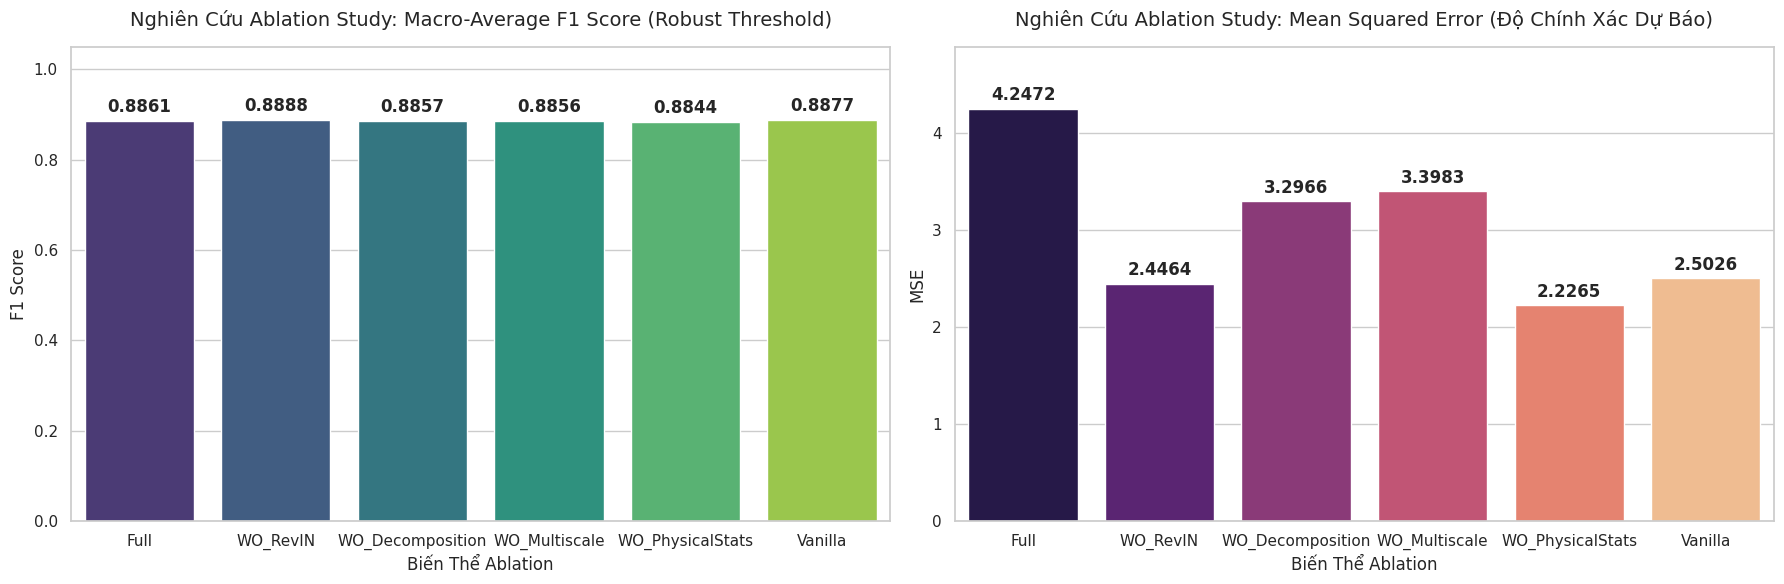

In [10]:
if results:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    variants = list(results.keys())
    f1_robust = [results[v]["F1 (Robust)"] for v in variants]
    mse_vals = [results[v]["MSE"] for v in variants]
    
    # 1. Biểu đồ cột cho F1 Score
    sns.barplot(x=variants, y=f1_robust, ax=axes[0], palette="viridis")
    axes[0].set_title("Nghiên Cứu Ablation Study: Macro-Average F1 Score (Robust Threshold)", fontsize=14, pad=15)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1 Score", fontsize=12)
    axes[0].set_xlabel("Biến Thể Ablation", fontsize=12)
    for i, v in enumerate(f1_robust):
        axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        
    # 2. Biểu đồ cột cho MSE
    sns.barplot(x=variants, y=mse_vals, ax=axes[1], palette="magma")
    axes[1].set_title("Nghiên Cứu Ablation Study: Mean Squared Error (Độ Chính Xác Dự Báo)", fontsize=14, pad=15)
    axes[1].set_ylabel("MSE", fontsize=12)
    axes[1].set_xlabel("Biến Thể Ablation", fontsize=12)
    max_mse = max(mse_vals) if len(mse_vals) > 0 else 1.0
    axes[1].set_ylim(0, max_mse * 1.15)
    for i, v in enumerate(mse_vals):
        axes[1].text(i, v + (max_mse * 0.02), f"{v:.4f}", ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")